# 1. Canonical mini-ELF

The simplest pipeline: a 15-segment ring of circular sub-apertures, no atmosphere, no coronagraph. Loaded from the bundled `elf_15seg` preset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from telescope_sim import TelescopeSim

sim = TelescopeSim.from_preset("elf_15seg")
print("correctors:", list(sim.correctors))
print("focal planes:", list(sim.focal_planes))


correctors: ['segments']
focal planes: ['filter1', 'filter2']


Sample at rest (no actuators applied) and inspect the result. The output `images['psf']` is channels-last over filters; the preset has two filters at 500 nm and 1 µm.

psf shape: (128, 128, 2) strehls: {'filter1': 1.0, 'filter2': 1.0}


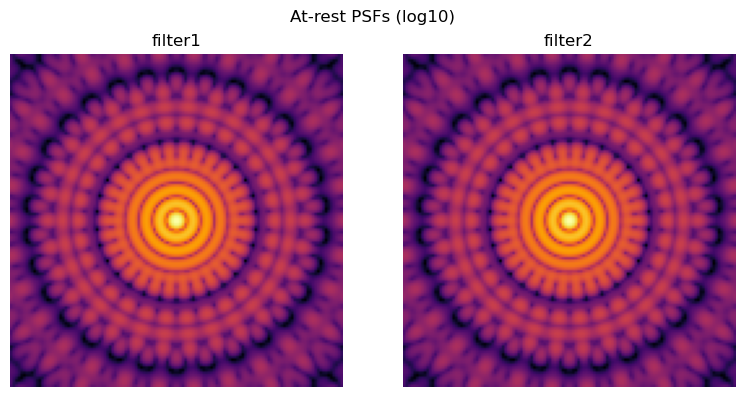

In [2]:
out = sim.sample(meas_strehl=True)
psf = out["images"]["psf"]
print("psf shape:", psf.shape, "strehls:", out["strehls"])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (filt, idx) in zip(axes, list(sim.focal_planes.items())):
    im = ax.imshow(np.log10(psf[..., 0] + 1e-8), cmap="inferno")
    ax.set_title(filt)
    ax.set_axis_off()
fig.suptitle("At-rest PSFs (log10)")
plt.tight_layout()
plt.show()


Apply random per-segment piston/tip/tilt errors and resample.

strehls with errors: {'filter1': 0.050454922839294536, 'filter2': 0.11317076514003656}


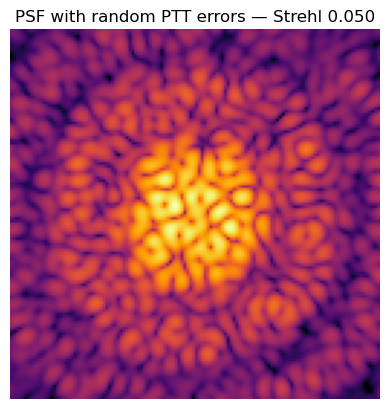

In [3]:
rng = np.random.default_rng(0)
ptt = rng.normal(scale=0.1, size=(15, 3))
out = sim.sample(actuations={"segments": ptt}, meas_strehl=True)
print("strehls with errors:", out["strehls"])

plt.imshow(np.log10(out["images"]["psf"][..., 0] + 1e-8), cmap="inferno")
plt.title(f"PSF with random PTT errors — Strehl {out['strehls']['filter1']:.3f}")
plt.axis("off")
plt.show()


## Detector noise

The `noisy_detector` post-processor wraps HCIPy's `NoisyDetector` (read noise + dark current + flat-field + optional photon shot noise). It's a single-focal-plane processor — its underlying detector needs exactly one focal grid — so the simplest demo derives a single-filter config from the preset and stacks `noisy_detector` under the existing `intensity` tap.

Per-sample photon flux is plumbed through `sim.sample(output_overrides={"psf": {"int_phot_flux": ...}})`: the same noisy sim covers a wide flux range without rebuilding.

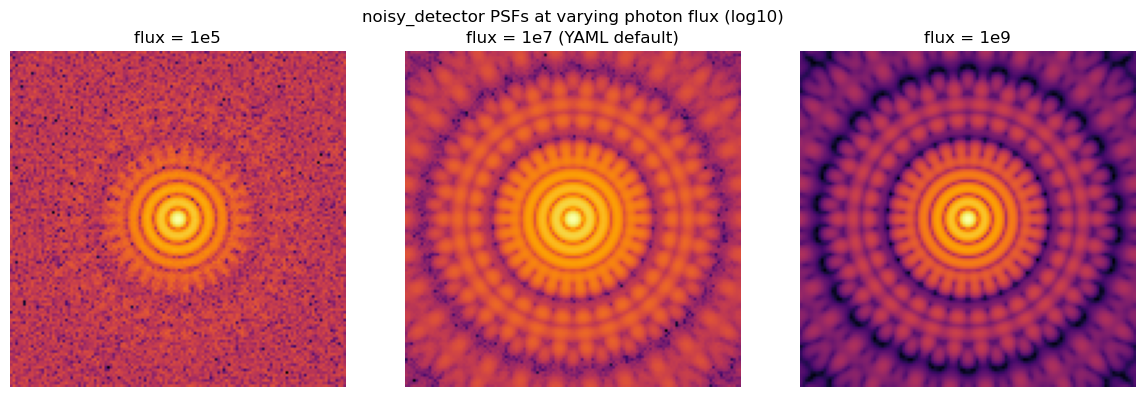

In [4]:
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

# Derived single-filter config so the single-focal-plane noisy_detector
# constraint is satisfied. Re-uses the 15-segment ELF aperture + PTT
# corrector from the preset.
noisy_cfg = {
    'pupil': {'resolution': 256, 'extent': 3.1563881637},
    'aperture': {
        'type': 'segmented_circular',
        'segment_diameter': 0.5197792270,
        'layout': 'elf', 'n_segments': 15, 'ring_radius': 1.25,
        'supersample': 16,
    },
    'correctors': {
        'segments': {
            'type': 'segmented_ptt',
            'piston_scale': 1.0e-6, 'tip_tilt_scale': 1.0e-6,
            'wavefront_role': 'actuate',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['segments'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 0.5e-6,
            'focal_extent': 1.0, 'focal_res': 128,
            'fractional_bandwidth': 0.05, 'num_samples': 5,
        },
    },
    'outputs': {
        'psf': {
            'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
            'post_processing': [
                {'type': 'noisy_detector',
                 'int_phot_flux': 1.0e7,
                 'detector': {
                     'read_noise': 5.0,
                     'dark_current_rate': 0.0,
                     'flat_field': 0.0,
                     'include_photon_noise': True,
                 }},
            ],
        },
    },
}
noisy_sim = build(SimConfig.model_validate(noisy_cfg))
np.random.seed(0)
out_clean = noisy_sim.sample()  # default flux = 1e7 photons/m^2
out_low = noisy_sim.sample(output_overrides={'psf': {'int_phot_flux': 1.0e5}})
out_high = noisy_sim.sample(output_overrides={'psf': {'int_phot_flux': 1.0e9}})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, out_i, title in zip(
    axes,
    [out_low, out_clean, out_high],
    ['flux = 1e5', 'flux = 1e7 (YAML default)', 'flux = 1e9'],
):
    img = out_i['images']['psf'][..., 0]
    ax.imshow(np.log10(img + 1e-3), cmap='inferno')
    ax.set_title(title)
    ax.set_axis_off()
fig.suptitle('noisy_detector PSFs at varying photon flux (log10)')
plt.tight_layout()
plt.show()


## Extended-source imaging via `convolve_image`

The `convolve_image` post-processor convolves a caller-supplied scene with the focal-plane PSF (normalized by the at-rest reference PSF sum, so the kernel integrates to ~1). Stacked **before** `noisy_detector`, the chain is `intensity → convolve_image → noisy_detector` — the physically correct order for noisy extended-source imaging.

Below the convolve scene is injected per-sample via `output_overrides`, so the same sim can imaging different scenes without rebuilding. To compare convolution alone vs. convolution + noise we build two sims (post-processing chains are fixed at sim-build time).

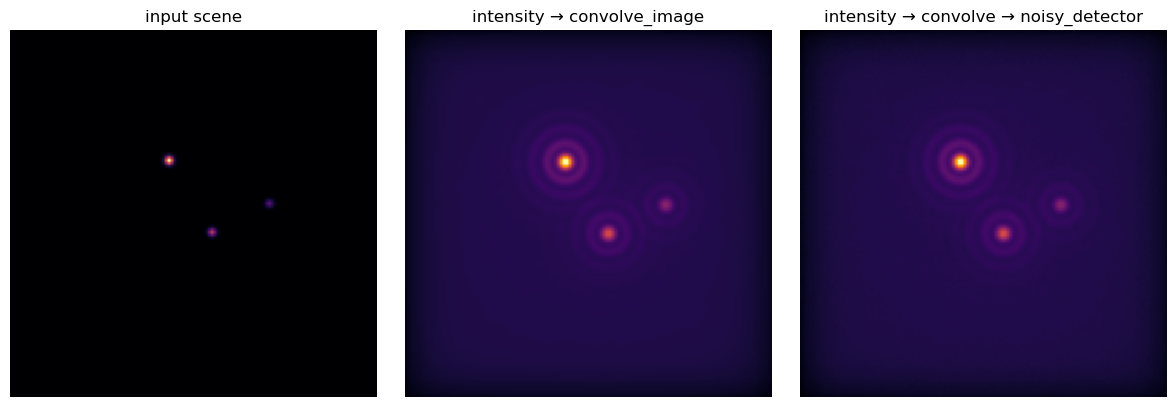

In [5]:
# Build a synthetic extended scene (three off-axis point sources +
# a smooth background) at the same resolution as the focal grid.
scene = np.zeros((128, 128), dtype=np.float64)
ys, xs = np.indices(scene.shape)
for cy, cx, amp, sig in [(45, 55, 3.0, 1.0),
                          (70, 70, 1.5, 1.0),
                          (60, 90, 0.8, 1.0)]:
    scene += amp * np.exp(-((ys - cy) ** 2 + (xs - cx) ** 2) / (2 * sig ** 2))
scene += 0.05  # uniform background

# Sim A: convolve only. The 'image' field is omitted, so the scene
# must come in per-sample via output_overrides.
clean_cfg = {**noisy_cfg}
clean_cfg['outputs'] = {
    'psf': {
        'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
        'post_processing': [
            {'type': 'convolve_image'},
        ],
    },
}
clean_sim = build(SimConfig.model_validate(clean_cfg))
out_clean_scene = clean_sim.sample(
    output_overrides={'psf': {'convolve_image': scene}}
)

# Sim B: convolve + noise. Same per-sample scene injection.
convolve_cfg = {**noisy_cfg}
convolve_cfg['outputs'] = {
    'psf': {
        'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
        'post_processing': [
            {'type': 'convolve_image'},
            {'type': 'noisy_detector',
             'int_phot_flux': 5.0e7,
             'detector': {
                 'read_noise': 5.0, 'dark_current_rate': 0.0,
                 'flat_field': 0.0, 'include_photon_noise': True,
             }},
        ],
    },
}
scene_sim = build(SimConfig.model_validate(convolve_cfg))
np.random.seed(0)
out_noisy_scene = scene_sim.sample(
    output_overrides={'psf': {'convolve_image': scene}}
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(scene, cmap='inferno')
axes[0].set_title('input scene')
axes[0].set_axis_off()
axes[1].imshow(out_clean_scene['images']['psf'][..., 0], cmap='inferno')
axes[1].set_title('intensity → convolve_image')
axes[1].set_axis_off()
axes[2].imshow(out_noisy_scene['images']['psf'][..., 0], cmap='inferno')
axes[2].set_title('intensity → convolve → noisy_detector')
axes[2].set_axis_off()
plt.tight_layout()
plt.show()
